In [102]:
# Cell 1: Libraries and Settings
import pandas as pd             # For data manipulation and analysis
import numpy as np              # For numerical operations, especially with arrays
import matplotlib.pyplot as plt # For creating static, interactive, and animated visualizations
import seaborn as sns           # For statistical data visualization based on matplotlib
import glob, os, re, time, math, warnings # Standard utility modules
from scipy.linalg import sqrtm, inv # For matrix square root and inverse in whitening transform
from scipy.stats import kurtosis, skew, entropy, ttest_ind # For statistical feature calculation
from scipy.interpolate import griddata # For interpolating data (used in whitening)
from IPython.display import display     # For displaying DataFrames nicely in Jupyter

warnings.filterwarnings('ignore') # Suppress warnings to keep output clean
plt.rcParams['figure.figsize'] = (16, 6) # Set default figure size for matplotlib plots
sns.set_style('whitegrid')       # Set seaborn style for plots

# -- Grid Settings -------------------------------------------
ROWS, COLS         = 34, 16  # Dimensions of the sensor grid
CENTER_ROW         = 16.5    # Center row coordinate for radial calculations
CENTER_COL         = 7.5     # Center column coordinate for radial calculations
RADIUS             = 6.0     # Radius for defining the circular mask
EPS                = 1e-10   # A small epsilon value to prevent division by zero
WEIGHT_THRESHOLD   = 0.01    # Threshold for active pixel weighting
STABLE_WINDOW_TRIM = 0.20    # Trim percentage for stable window (not used in this snippet but part of original context)

# -- Circular Mask --------------------------------------------
_ri, _ci = np.indices((ROWS, COLS)) # Get row and column indices for the grid
MASK_2D  = np.sqrt((_ri - CENTER_ROW)**2 + (_ci - CENTER_COL)**2) <= RADIUS # Create a circular mask based on radius
N_ACTIVE_PIXELS = int(MASK_2D.sum()) # Count the number of active pixels within the mask

# -- Fixed Coordinates (Calculated Once) ------------------------
_y_idx, _x_idx = np.indices((ROWS, COLS)) # Get y and x indices
COORDS_FLAT     = np.stack([_x_idx.ravel(), _y_idx.ravel()], axis=0).astype(float) # Flatten coordinates for vectorized operations

print(f"Settings Ready -- Number of Active Pixels in Sensor: {N_ACTIVE_PIXELS}")

Settings Ready -- Number of Active Pixels in Sensor: 112


In [104]:
# Cell 2: Signal Processing and Cleaning Functions

def apply_energy_normalization(frame_2d):
    """Normalizes the energy of a 2D frame (e.g., sensor data)."""
    e = np.clip(frame_2d, 0, None) # Clip values to be non-negative
    s = np.sum(e)                   # Calculate the sum of energy
    return e / s if s > 0 else e    # Return normalized energy or original if sum is zero

def apply_whitening_transform(energy_map):
    """Applies a whitening transform to decorrelate and normalize data spatial distribution.
       This function aims to make the data distribution more spherical, improving feature robustness.
    """
    rows, cols   = energy_map.shape
    # Generate coordinates for each pixel in the 2D map
    coords       = np.stack([np.arange(cols * rows) % cols,
                              np.arange(cols * rows) // cols], axis=0).astype(float)
    weights      = energy_map.ravel() # Flatten the energy map to use as weights
    total_weight = np.sum(weights)    # Sum of all weights

    if total_weight <= 0:
        return energy_map # If no energy, return original map

    # Calculate weighted mean position and centered coordinates
    mean_pos = np.sum(coords * weights, axis=1, keepdims=True) / total_weight
    centered = coords - mean_pos
    # Calculate weighted covariance matrix
    cov      = (centered * weights) @ centered.T / total_weight
    cov      = (cov + cov.T) / 2 # Ensure covariance matrix is symmetric

    try:
        # Compute whitening matrix W using inverse square root of covariance
        W       = inv(sqrtm(cov + np.eye(2) * 1e-6)) # Add small identity for numerical stability
        wc      = W @ centered # Apply whitening transform to centered coordinates
        wx, wy  = wc[0], wc[1]  # Extract whitened x and y coordinates

        def rescale(arr, lo, hi):
            """Rescales an array to a new min/max range."""
            a, b = arr.min(), arr.max()
            if a == b: return np.full_like(arr, (lo + hi) / 2) # Handle case where all values are the same
            return (arr - a) / (b - a) * (hi - lo) + lo # Linear rescaling

        # Rescale whitened coordinates to fit original grid dimensions for interpolation
        wx_s   = rescale(wx, 0, cols - 1)
        wy_s   = rescale(wy, 0, rows - 1)
        gy, gx = np.mgrid[0:rows, 0:cols] # Create a grid for interpolation
        # Interpolate the whitened energy map back to the original grid
        w_map  = griddata(np.stack([wx_s, wy_s], axis=1),
                          weights, (gx, gy),
                          method='linear', fill_value=0.0)
        return np.clip(w_map, 0, None) # Clip to non-negative values

    except Exception as e:
        warnings.warn(f"Whitening failed: {e}") # Warn if whitening fails
        return energy_map # Return original map if whitening fails

def apply_zscore_normalization(energy_map):
    """Applies Z-score normalization and then rescales to [0, 1] range."""
    mean_v = np.mean(energy_map) # Calculate mean of the energy map
    std_v  = np.std(energy_map)  # Calculate standard deviation
    z      = (energy_map - mean_v) / (std_v if std_v > 0 else 1.0) # Apply Z-score (handle std=0)
    z      = z - np.min(z)       # Shift minimum to 0
    s      = np.sum(z)           # Calculate sum for final normalization
    return z / s if s > 0 else z # Rescale to sum to 1, or return original if sum is zero

print("Cleaning Functions (Pipeline) Ready")

Cleaning Functions (Pipeline) Ready


In [105]:
# Cell 2: Signal Processing and Cleaning Functions

def apply_energy_normalization(frame_2d):
    """Normalizes the energy of a 2D frame (e.g., sensor data)."""
    e = np.clip(frame_2d, 0, None) # Clip values to be non-negative
    s = np.sum(e)                   # Calculate the sum of energy
    return e / s if s > 0 else e    # Return normalized energy or original if sum is zero

def apply_whitening_transform(energy_map):
    """Applies a whitening transform to decorrelate and normalize data spatial distribution.
       This function aims to make the data distribution more spherical, improving feature robustness.
    """
    rows, cols   = energy_map.shape
    # Generate coordinates for each pixel in the 2D map
    coords       = np.stack([np.arange(cols * rows) % cols,
                              np.arange(cols * rows) // cols], axis=0).astype(float)
    weights      = energy_map.ravel() # Flatten the energy map to use as weights
    total_weight = np.sum(weights)    # Sum of all weights

    if total_weight <= 0:
        return energy_map # If no energy, return original map

    # Calculate weighted mean position and centered coordinates
    mean_pos = np.sum(coords * weights, axis=1, keepdims=True) / total_weight
    centered = coords - mean_pos
    # Calculate weighted covariance matrix
    cov      = (centered * weights) @ centered.T / total_weight
    cov      = (cov + cov.T) / 2 # Ensure covariance matrix is symmetric

    try:
        # Compute whitening matrix W using inverse square root of covariance
        W       = inv(sqrtm(cov + np.eye(2) * 1e-6)) # Add small identity for numerical stability
        wc      = W @ centered # Apply whitening transform to centered coordinates
        wx, wy  = wc[0], wc[1]  # Extract whitened x and y coordinates

        def rescale(arr, lo, hi):
            """Rescales an array to a new min/max range."""
            a, b = arr.min(), arr.max()
            if a == b: return np.full_like(arr, (lo + hi) / 2) # Handle case where all values are the same
            return (arr - a) / (b - a) * (hi - lo) + lo # Linear rescaling

        # Rescale whitened coordinates to fit original grid dimensions for interpolation
        wx_s   = rescale(wx, 0, cols - 1)
        wy_s   = rescale(wy, 0, rows - 1)
        gy, gx = np.mgrid[0:rows, 0:cols] # Create a grid for interpolation
        # Interpolate the whitened energy map back to the original grid
        w_map  = griddata(np.stack([wx_s, wy_s], axis=1),
                          weights, (gx, gy),
                          method='linear', fill_value=0.0)
        return np.clip(w_map, 0, None) # Clip to non-negative values

    except Exception as e:
        warnings.warn(f"Whitening failed: {e}") # Warn if whitening fails
        return energy_map # Return original map if whitening fails

def apply_zscore_normalization(energy_map):
    """Applies Z-score normalization and then rescales to [0, 1] range."""
    mean_v = np.mean(energy_map) # Calculate mean of the energy map
    std_v  = np.std(energy_map)  # Calculate standard deviation
    z      = (energy_map - mean_v) / (std_v if std_v > 0 else 1.0) # Apply Z-score (handle std=0)
    z      = z - np.min(z)       # Shift minimum to 0
    s      = np.sum(z)           # Calculate sum for final normalization
    return z / s if s > 0 else z # Rescale to sum to 1, or return original if sum is zero

print("Cleaning Functions (Pipeline) Ready")

Cleaning Functions (Pipeline) Ready


In [92]:
# Cell 3: Helper Functions
_COND_PATTERN = re.compile(r'[-_]?[FMfm][-_]?([LN])\d*$|[-_]([LN])\d*$') # Regex to extract 'L' or 'N' from filenames

def parse_condition(filepath):
    """Extracts the 'Condition' (Normal or Low Iron) from a given file path."""
    name  = os.path.basename(filepath).upper().replace('.CSV', '') # Get uppercase filename without extension
    match = _COND_PATTERN.search(name) # Search for the condition pattern
    if not match: return None          # Return None if no match is found
    letter = match.group(1) or match.group(2) # Get the matched letter ('L' or 'N')
    return 'Normal' if letter == 'N' else 'Low Iron' # Return 'Normal' or 'Low Iron'

def top_n_energy(sorted_desc, total, pct):
    """Calculates the proportion of total energy accounted for by the top 'pct' of sorted values."""
    k = max(1, int(np.ceil(len(sorted_desc) * pct))) # Determine the number of top elements to consider
    return np.sum(sorted_desc[:k]) / (total + EPS) # Sum energy of top elements and divide by total energy

print("Helper Functions Ready")

Helper Functions Ready


In [106]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [107]:
# Cell 4: High-Speed Feature Extraction with File Printing (Threading Version)
from joblib import Parallel, delayed # For parallelizing tasks
import time                         # For timing execution
import datetime                     # For displaying elapsed time
import glob, os                     # For file system operations
import pandas as pd                 # For data handling
import numpy as np                  # For numerical operations
from scipy.stats import kurtosis, skew, entropy # For statistical feature calculations

folder_path = '/content/drive/MyDrive/Data_samples' # Define the path where CSV data files are located
csv_files   = glob.glob(os.path.join(folder_path, "*.csv")) # Find all CSV files in the specified folder

if len(csv_files) == 0:
    print("No files found! Please check the path.") # Print error if no files are found
else:
    print(f"Excellent! {len(csv_files)} files found.") # Confirm number of files found
    print("Starting parallel processing (files will appear here directly)...") # Indicate start of parallel processing

    start_time = time.time() # Record start time for performance measurement

    def process_single_file(file):
        """Extracts various features from a single CSV file containing sensor data."""
        # Print the file name immediately when processing starts (now it will appear in Jupyter immediately)
        print(f"Processing: {os.path.basename(file)} ...") # Print filename being processed

        file_dataset = [] # Initialize list to store features for frames in this file
        condition = parse_condition(file) # Determine the condition (Normal/Low Iron) from filename
        if condition is None: return file_dataset # Skip file if condition cannot be parsed

        try:
            df = pd.read_csv(file, on_bad_lines='skip') # Read CSV, skipping bad lines
            for idx in range(len(df)): # Iterate through each frame (row) in the DataFrame
                # Extract delta values, cleaning up string artifacts
                delta_str = (str(df['delta_values'].iloc[idx]).replace('OK 34 16', '').replace('\n', ''))
                try: delta_raw = np.array([float(x.strip()) for x in delta_str.split(',') if x.strip()]) # Convert string to float array
                except: continue # Skip if conversion fails

                if len(delta_raw) != 544: continue # Ensure raw data has expected length (34x16 pixels)

                raw_2d           = delta_raw.reshape(ROWS, COLS).copy() # Reshape to 2D grid
                raw_2d[~MASK_2D] = 0 # Apply the circular mask, setting outside pixels to 0
                energy_map       = apply_energy_normalization(raw_2d) # Normalize energy
                whitened_map     = apply_whitening_transform(energy_map) # Apply whitening transform
                final_map        = apply_zscore_normalization(whitened_map) # Apply Z-score normalization

                flat   = final_map.flatten() # Flatten the final map
                active = flat[flat > 0]       # Get only active (non-zero) pixels
                if len(active) < 5: continue  # Skip if too few active pixels

                ff = {'source_file': file, 'Condition': condition, 'frame_index': idx} # Initialize feature dictionary

                # Calculate basic signal characteristics
                p_norm       = active / (np.sum(active) + EPS) # Normalized active pixel values
                sorted_desc  = np.sort(active)[::-1]           # Active pixels sorted descending
                sorted_asc   = sorted_desc[::-1]              # Active pixels sorted ascending
                total_energy = np.sum(active)                 # Total energy of active pixels
                n_px         = len(active)                    # Number of active pixels

                ff['signal_mean']              = np.mean(active)
                ff['signal_std']               = np.std(active)
                ff['signal_variance']          = np.var(active)
                ff['active_area']              = n_px
                ff['peak_amplitude']           = sorted_desc[0]
                ff['signal_power']             = np.mean(active ** 2)
                ff['rms_amplitude']            = np.sqrt(ff['signal_power'])
                ff['crest_factor']             = ff['peak_amplitude'] / (ff['rms_amplitude'] + EPS)
                ff['kurtosis']                 = kurtosis(active, fisher=True)
                ff['skewness']                 = skew(active)
                ff['coefficient_of_variation'] = ff['signal_std'] / (ff['signal_mean'] + EPS)

                # Calculate spatial entropy and normalized entropy
                raw_ent               = entropy(p_norm)
                ff['spatial_entropy'] = raw_ent
                max_ent               = np.log(n_px) if n_px > 1 else 1.0
                ff['entropy_norm']    = raw_ent / (max_ent + EPS)

                # Calculate energy concentration at top percentages
                ff['top_50_energy'] = top_n_energy(sorted_desc, total_energy, 0.50)
                ff['top_25_energy'] = top_n_energy(sorted_desc, total_energy, 0.25)
                ff['top_10_energy'] = top_n_energy(sorted_desc, total_energy, 0.10)

                # Calculate Gini coefficient for energy distribution inequality
                cumsum = np.cumsum(sorted_asc)
                if cumsum[-1] > 0:
                    gini_raw = (2 * np.sum(np.arange(1, n_px + 1) * sorted_asc) / (n_px * cumsum[-1]) - (n_px + 1) / n_px)
                    ff['gini_coefficient'] = float(np.clip(gini_raw, 0.0, 1.0))
                else: ff['gini_coefficient'] = 0.0

                # Calculate effective area ratio and contact compactness
                p_sq_sum                   = np.sum(p_norm ** 2)
                ff['effective_area_ratio'] = (1.0 / (p_sq_sum + EPS)) / (N_ACTIVE_PIXELS + EPS)
                ff['contact_compactness']  = n_px / (N_ACTIVE_PIXELS + EPS)

                # Initialize dictionaries for radial and zonal features
                weights, t_w = flat, np.sum(flat)
                r_features   = {f'ring{k}_energy': 0.0 for k in range(1, 6)}
                z_features   = {'core_energy': 0.0, 'mid_energy': 0.0, 'boundary_energy': 0.0, 'center_dominance': 0.0}
                decay_features = {'radial_slope': 0.0, 'radial_curvature': 0.0, 'radial_spread': 0.0, 'radial_variance': 0.0, 'radial_std': 0.0, 'radial_kurtosis': 0.0}

                if t_w > 0: # Proceed only if there is total weight (energy)
                    # Calculate weighted mean position and radial distances
                    mean_pos    = np.sum(COORDS_FLAT * weights, axis=1, keepdims=True) / t_w
                    centered    = COORDS_FLAT - mean_pos
                    radial_dist = np.sqrt(centered[0] ** 2 + centered[1] ** 2)
                    # Mask for active pixels above a certain weight threshold
                    active_mask = weights > (weights.max() * WEIGHT_THRESHOLD)

                    if active_mask.sum() >= 5: # Ensure enough active pixels for robust calculations
                        active_dists, active_weights, t_w_active = radial_dist[active_mask], weights[active_mask], np.sum(weights[active_mask])

                        # Calculate energy in concentric rings (5 rings based on percentiles)
                        bounds_r = ([0] + np.percentile(active_dists, [20, 40, 60, 80]).tolist() + [np.inf])
                        for k in range(5):
                            mask_k = ((radial_dist >= bounds_r[k]) & (radial_dist <  bounds_r[k + 1]))
                            r_features[f'ring{k+1}_energy'] = (np.sum(weights[mask_k]) / (t_w_active + EPS))

                        # Calculate energy in core, mid, and boundary zones (based on percentiles)
                        p33, p66 = np.percentile(active_dists, [33, 66])
                        c_e = np.sum(weights[radial_dist < p33]) / (t_w_active + EPS)
                        m_e = np.sum(weights[(radial_dist >= p33) & (radial_dist < p66)]) / (t_w_active + EPS)
                        b_e = np.sum(weights[radial_dist >= p66]) / (t_w_active + EPS)
                        z_features = {'core_energy': c_e, 'mid_energy': m_e, 'boundary_energy': b_e, 'center_dominance': c_e - b_e}

                        # Calculate radial decay features using polynomial fit
                        norm_dist    = active_dists / (active_dists.max() + EPS)
                        norm_weights = active_weights / (active_weights.sum() + EPS)

                        decay_features['radial_slope']     = np.polyfit(norm_dist, active_weights, 1, w=norm_weights)[0]
                        decay_features['radial_curvature'] = np.polyfit(norm_dist, active_weights, 2, w=norm_weights)[0]
                        r_spread = np.sum(norm_dist * norm_weights)
                        r_var    = np.sum(norm_weights * (norm_dist - r_spread) ** 2)
                        decay_features['radial_spread']    = r_spread
                        decay_features['radial_variance']  = r_var
                        decay_features['radial_std']       = np.sqrt(r_var)

                        if r_var > EPS:
                            decay_features['radial_kurtosis'] = np.sum(norm_weights * (norm_dist - r_spread) ** 4) / (r_var ** 2 + EPS)

                ff.update(r_features) # Add ring features to the dictionary
                ff.update(z_features) # Add zonal features
                ff.update(decay_features) # Add radial decay features

                # Calculate derived ratio features
                ff['ring_decay_ratio']    = r_features['ring1_energy'] / (r_features['ring5_energy'] + EPS)
                ff['inner_outer_ratio']   = ((r_features['ring1_energy'] + r_features['ring2_energy']) / (r_features['ring4_energy'] + r_features['ring5_energy'] + EPS))
                ff['core_mid_ratio']      = z_features['core_energy'] / (z_features['mid_energy'] + EPS)
                ff['core_boundary_ratio'] = z_features['core_energy'] / (z_features['boundary_energy'] + EPS)
                ff['mid_boundary_ratio']  = z_features['mid_energy']  / (z_features['boundary_energy'] + EPS)

                file_dataset.append(ff) # Add the compiled features for this frame to the list
        except Exception as e: pass # Catch any errors during processing a file and skip it
        return file_dataset # Return the list of features for all frames in this file

    # The magic change here: using backend='loky' for parallel processing, allowing direct printing in Jupyter.
    # n_jobs=-1 uses all available CPU cores.
    parallel_results = Parallel(n_jobs=-1, backend='loky')(delayed(process_single_file)(f) for f in csv_files)

    # Aggregate results
    # Aggregate results from all processed files into a single list of dictionaries
    ml_dataset = [item for sublist in parallel_results for item in sublist]
    ml_df  = pd.DataFrame(ml_dataset) # Convert the list of features into a pandas DataFrame
    # Calculate the number of actual features (excluding metadata columns)
    n_feat = len([c for c in ml_df.columns if c not in ['source_file', 'Condition', 'frame_index']])

    print("\n")
    # Print completion message and total time taken
    print(f"Task Completed! Time Taken: {str(datetime.timedelta(seconds=int(time.time() - start_time)))}")
    # Print summary of the extracted data (number of frames and features)
    print(f"Total Data: {len(ml_df):,} Frames x {n_feat} Features")
    print("")

Excellent! 71 files found.
Starting parallel processing (files will appear here directly)...


Task Completed! Time Taken: 0:03:07
Total Data: 18,435 Frames x 39 Features



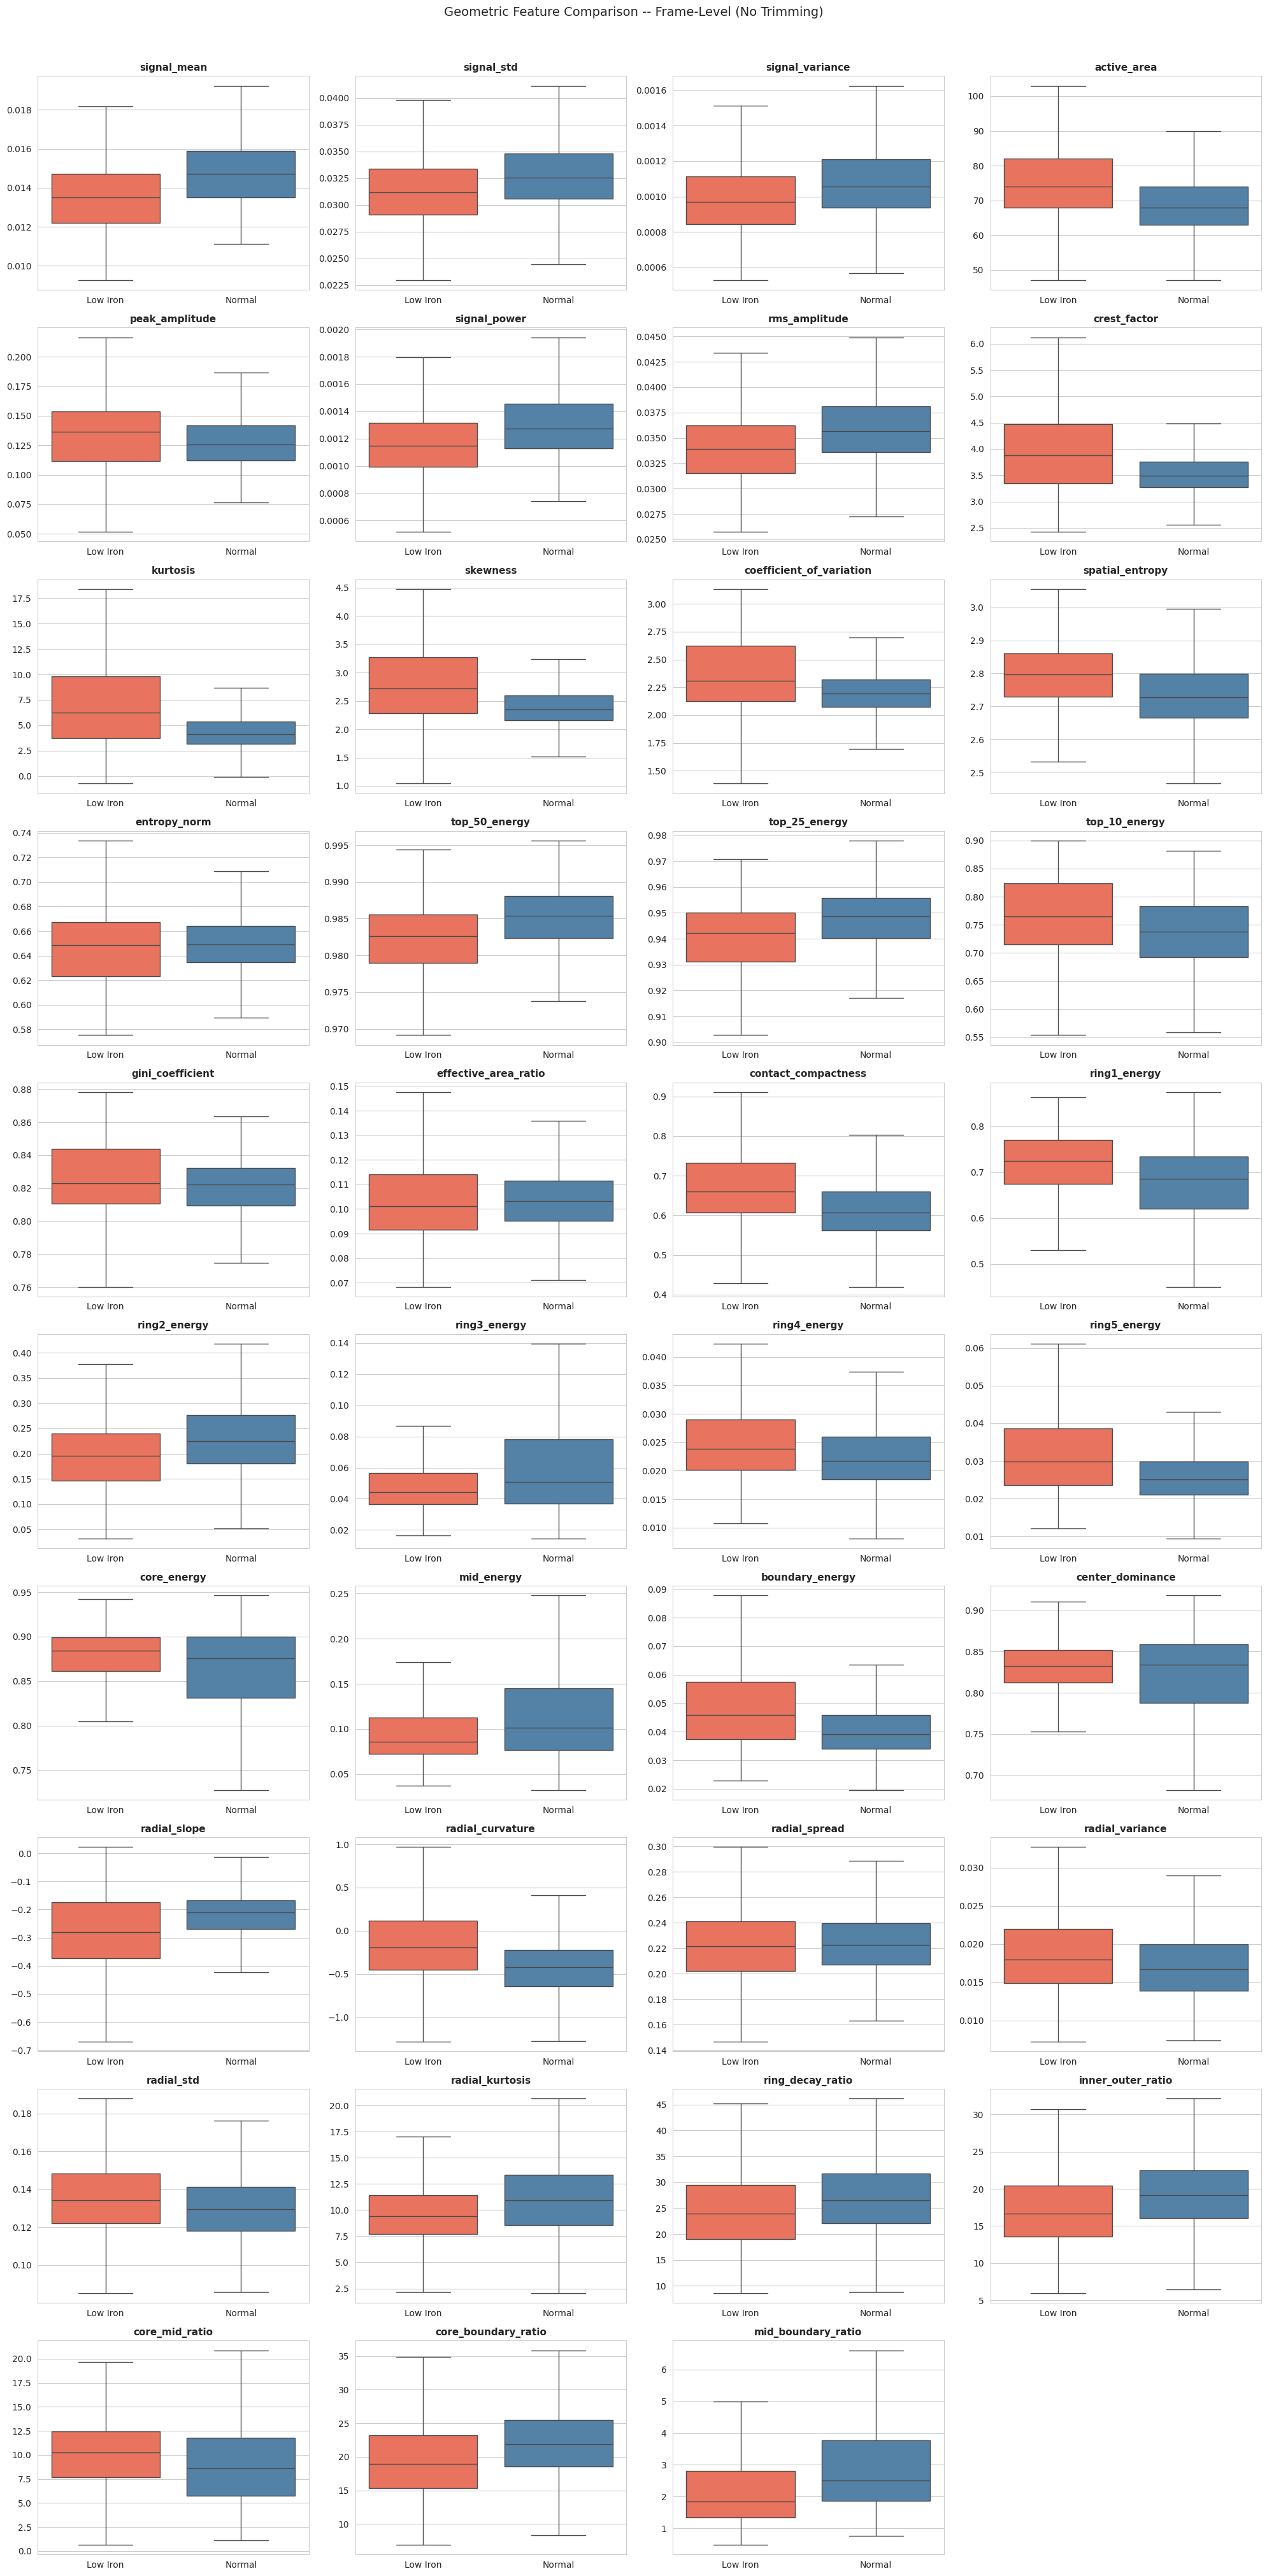

Plotting Complete


In [108]:
# Cell 6: Boxplots for Comparison
exclude_meta = ['source_file', 'Condition', 'frame_index']
plot_features = [c for c in ml_df.columns if c not in exclude_meta]

if not ml_df.empty and plot_features:
    cols_count = 4
    rows_count = math.ceil(len(plot_features) / cols_count)
    palette    = {'Normal': 'steelblue', 'Low Iron': 'tomato'}

    fig, axes = plt.subplots(rows_count, cols_count, figsize=(cols_count * 5, rows_count * 4))
    axes = axes.flatten()

    for fi, feat in enumerate(plot_features):
        sns.boxplot(data=ml_df, x='Condition', y=feat,
                    palette=palette, ax=axes[fi], showfliers=False)
        axes[fi].set_title(feat, fontsize=11, fontweight='bold')
        axes[fi].set_xlabel('')
        axes[fi].set_ylabel('')

    for j in range(fi + 1, len(axes)):
        fig.delaxes(axes[j])

    plt.suptitle('Geometric Feature Comparison -- Frame-Level (No Trimming)', fontsize=14, y=1.01)
    plt.tight_layout()
    plt.show()
    print("Plotting Complete")

In [109]:
# Cell 7: Feature Statistical Evaluation (Cohen's d & P-value)
normal_df   = ml_df[ml_df['Condition'] == 'Normal']
low_iron_df = ml_df[ml_df['Condition'] == 'Low Iron']

results = []
for feat in plot_features:
    n_vals = normal_df[feat].dropna()
    l_vals = low_iron_df[feat].dropna()

    n_mean = n_vals.mean()
    l_mean = l_vals.mean()
    diff   = l_mean - n_mean

    if len(n_vals) > 1 and len(l_vals) > 1:
        _, p_val   = ttest_ind(n_vals, l_vals, equal_var=False)
        n1, n2     = len(n_vals), len(l_vals)
        v1, v2     = np.var(n_vals, ddof=1), np.var(l_vals, ddof=1)
        pooled_std = np.sqrt(((n1-1)*v1 + (n2-1)*v2) / (n1+n2-2))
        d_val      = diff / (pooled_std + EPS)
    else:
        p_val, d_val = 1.0, 0.0

    results.append({
        'Feature':       feat,
        'Normal Mean':   n_mean,
        'Low Iron Mean': l_mean,
        "Cohen's d":     d_val,
        'P-value':       p_val,
        'abs_d':         abs(d_val)
    })

results_df = (pd.DataFrame(results)
              .sort_values('abs_d', ascending=False)
              .drop(columns='abs_d')
              .reset_index(drop=True))

print("")
print("Statistical Analysis -- Frame-Level (No Trimming)")
print(f"Normal: {len(normal_df):,} frames | Low Iron: {len(low_iron_df):,} frames")
print("")
print(f"{'Feature':<32} | {'Normal':>10} | {'Low Iron':>10} | {'Cohen d':>9} | {'P-value':>10} | Evaluation")
print("-" * 112)

for _, row in results_df.iterrows():
    d, p = row["Cohen's d"], row['P-value']
    if   p >= 0.05:      ev = "Not Significant"
    elif abs(d) >= 0.8:  ev = "Excellent"
    elif abs(d) >= 0.5:  ev = "Good"
    else:                ev = "Weak"
    print(f"{row['Feature']:<32} | {row['Normal Mean']:>10.4f} | "
          f"{row['Low Iron Mean']:>10.4f} | {d:>+9.3f} | {p:>10.3e} | {ev}")

print("-" * 112)
display(results_df.style.background_gradient(subset=["Cohen's d"], cmap='coolwarm'))


Statistical Analysis -- Frame-Level (No Trimming)
Normal: 8,497 frames | Low Iron: 9,938 frames

Feature                          |     Normal |   Low Iron |   Cohen d |    P-value | Evaluation
----------------------------------------------------------------------------------------------------------------
active_area                      |    67.7896 |    75.8455 |    +0.755 |  0.000e+00 | Good
contact_compactness              |     0.6053 |     0.6772 |    +0.755 |  0.000e+00 | Good
kurtosis                         |     4.5661 |     6.9109 |    +0.741 |  0.000e+00 | Good
skewness                         |     2.4074 |     2.7745 |    +0.705 |  0.000e+00 | Good
signal_mean                      |     0.0150 |     0.0135 |    -0.678 |  0.000e+00 | Good
crest_factor                     |     3.5633 |     3.9235 |    +0.627 |  0.000e+00 | Good
radial_curvature                 |    -0.3959 |    -0.1409 |    +0.613 |  0.000e+00 | Good
ring5_energy                     |     0.0262 |     0.0

,Feature,Normal Mean,Low Iron Mean,Cohen's d,P-value
0,active_area,67.789573,75.845542,0.755367,0.000000
1,contact_compactness,0.605264,0.677192,0.755367,0.000000
2,kurtosis,4.566127,6.910893,0.740671,0.000000
3,skewness,2.407439,2.774550,0.705264,0.000000
4,signal_mean,0.015008,0.013536,-0.677794,0.000000
5,crest_factor,3.563307,3.923465,0.627354,0.000000
6,radial_curvature,-0.395895,-0.140899,0.613098,0.000000
7,ring5_energy,0.026163,0.031699,0.574775,0.000000
8,coefficient_of_variation,2.204886,2.360233,0.559825,0.000000
9,top_50_energy,0.984973,0.981665,-0.552636,0.000000


In [110]:
# Cell 8: Model Training and Evaluation (LOSO Validation + Multi-Core)
import os, re, time
import pandas as pd
from IPython.display import display
from sklearn.model_selection import LeaveOneGroupOut, cross_val_predict
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, recall_score, f1_score

from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier


def get_subject_id(filename):
    """Extracts a unique subject ID from a given filename."""
    name = os.path.basename(filename).upper()
    match = re.search(r'(?:R\d+[-_])([A-Z]+)', name)
    return match.group(1) if match else name


df_ml = ml_df.copy()
df_ml['subject_id'] = df_ml['source_file'].apply(get_subject_id)

exclude_cols = ['source_file', 'Condition', 'frame_index', 'subject_id']
features = [c for c in df_ml.columns if c not in exclude_cols]

X = df_ml[features]
y = (df_ml['Condition'] == 'Low Iron').astype(int)
groups = df_ml['subject_id']

print("")
print("Training Rigorous AI Algorithms (LOSO Validation)")
print(f"Input Frames: {len(X):,} | Extracted Features: {len(features)}")
print(f"Number of Independent Participants: {groups.nunique()}")
print("")

models = {
    'Random Forest (Random Forests)': RandomForestClassifier(n_estimators=100, class_weight='balanced', n_jobs=-1, random_state=42),
    'Extra Trees (Extra Trees)': ExtraTreesClassifier(n_estimators=100, class_weight='balanced', n_jobs=-1, random_state=42),
}

logo = LeaveOneGroupOut()
results = []
start_time = time.time()

print("Training models using all cores (this might take a minute)...\n")

for model_name, model in models.items():
    print(f"Processing: {model_name} ...", end=" ")

    pipeline = Pipeline([('scaler', StandardScaler()), ('classifier', model)])
    y_pred = cross_val_predict(pipeline, X, y, groups=groups, cv=logo, n_jobs=1)

    acc = accuracy_score(y, y_pred)
    recall = recall_score(y, y_pred)
    f1 = f1_score(y, y_pred)

    results.append({
        'Algorithm': model_name,
        'Accuracy': acc * 100,
        'Recall': recall * 100,
        'F1-Score': f1 * 100
    })
    print(f"Completed!")

results_df = pd.DataFrame(results).sort_values(by='F1-Score', ascending=False)

print(f"\nTotal training time for {len(models)} models: {(time.time() - start_time) / 60:.2f} minutes")

format_dict = {
    'Accuracy': '{:.2f}%',
    'Recall': '{:.2f}%',
    'F1-Score': '{:.2f}%'
}

display(results_df.style.format(format_dict).background_gradient(cmap='Greens'))


Training Rigorous AI Algorithms (LOSO Validation)
Input Frames: 18,435 | Extracted Features: 39
Number of Independent Participants: 18

Training models using all cores (this might take a minute)...

Processing: Random Forest (Random Forests) ... Completed!
Processing: Extra Trees (Extra Trees) ... Completed!

Total training time for 2 models: 4.94 minutes


,Algorithm,Accuracy,Recall,F1-Score
0,Random Forest (Random Forests),53.24%,56.53%,56.59%
1,Extra Trees (Extra Trees),52.99%,55.09%,55.82%


In [111]:
import pandas as pd, numpy as np, os, re
from sklearn.model_selection import LeaveOneGroupOut, cross_val_predict
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import f1_score, accuracy_score, recall_score, confusion_matrix
from sklearn.ensemble import ExtraTreesClassifier # Changed from RandomForestClassifier
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from scipy.stats import ttest_ind # Ensure ttest_ind is imported for feature stats

warnings.filterwarnings('ignore')

if 'ml_df' in locals():
    working_df = ml_df.copy()
else:
    working_df = pd.read_csv('Final_ML_Dataset.csv')

if 'subject_id' not in working_df.columns:
    def get_subject_id(filename):
        name = os.path.basename(str(filename)).upper()
        match = re.search(r'(?:R\d+[-_])([A-Z]+)', name)
        return match.group(1) if match else name
    working_df['subject_id'] = working_df['source_file'].apply(get_subject_id)

drop_cols = ['source_file', 'Condition', 'Target', 'frame_index', 'normalized_matrix',
             'raw_signal', 'final_signal', 'delta_values', 'unified_index', 'subject_id']

# --- Start: Re-creating feature statistical analysis DataFrame (from WLogyPjc--iD) ---
# This ensures the 'Feature' column is available for top_features selection.
# Assumes ml_df, plot_features, and EPS (from NhX41mDaKaif) are available from previous cells.
normal_df   = ml_df[ml_df['Condition'] == 'Normal']
low_iron_df = ml_df[ml_df['Condition'] == 'Low Iron']

results_feature_stats = [] # Renaming to avoid conflict
for feat in plot_features:
    n_vals = normal_df[feat].dropna()
    l_vals = low_iron_df[feat].dropna()

    n_mean = n_vals.mean()
    l_mean = l_vals.mean()
    diff   = l_mean - n_mean

    if len(n_vals) > 1 and len(l_vals) > 1:
        _, p_val   = ttest_ind(n_vals, l_vals, equal_var=False)
        n1, n2     = len(n_vals), len(l_vals)
        v1, v2     = np.var(n_vals, ddof=1), np.var(l_vals, ddof=1)
        pooled_std = np.sqrt(((n1-1)*v1 + (n2-1)*v2) / (n1+n2-2 + EPS)) # Added EPS for numerical stability
        d_val      = diff / (pooled_std + EPS)
    else:
        p_val, d_val = 1.0, 0.0

    results_feature_stats.append({
        'Feature':       feat,
        'Normal Mean':   n_mean,
        'Low Iron Mean': l_mean,
        "Cohen's d":     d_val,
        'P-value':       p_val,
        'abs_d':         abs(d_val)
    })

feature_stats_df = (pd.DataFrame(results_feature_stats)
              .sort_values('abs_d', ascending=False)
              .drop(columns='abs_d')
              .reset_index(drop=True))
# --- End: Re-creating feature statistical analysis DataFrame ---

top_features = feature_stats_df['Feature'].head(15).tolist()
X_full = working_df[top_features].fillna(0)
y = (working_df['Condition'] == 'Low Iron').astype(int)
groups = working_df['subject_id']

print("")
print("Extra Trees -- Feature Selection + Hyperparameter Tuning (Patient Voting)") # Changed model name
print(f"Features Pool: {len(top_features)} | n_estimators tested: {n_estimators_values}")
print("")

best_f1, best_features, best_results = 0, [], None
best_n_est = None

# Store results for each feature set, to pick the overall best later
all_step_results = []

for n_est in n_estimators_values:
    print(f"\nTesting Extra Trees (n_estimators = {n_est})...") # Changed model name

    current_features, remaining = [], list(top_features)

    for step in range(1, MAX_FEATURES + 1):
        best_step_f1, best_feat = -1, None
        candidate_results = {}

        for candidate in remaining:
            X_sub = X_full[current_features + [candidate]]
            pipeline = Pipeline([
                ('scaler', StandardScaler()),
                ('classifier', ExtraTreesClassifier( # Changed from RandomForestClassifier
                    n_estimators=n_est, class_weight='balanced',
                    n_jobs=-1, random_state=42))
            ])
            # Changed n_jobs from 1 to -1 to utilize all available CPU cores for faster execution
            y_pred = cross_val_predict(pipeline, X_sub, y, groups=groups, cv=logo, n_jobs=-1)
            voting = pd.DataFrame({'Subject': groups, 'True': y, 'Pred': y_pred})
            pat = voting.groupby('Subject').agg(
                True_Condition=('True', 'first'),
                Final_Diagnosis=('Pred', lambda x: x.mode()[0])
            ).reset_index()
            f1 = f1_score(pat['True_Condition'], pat['Final_Diagnosis']) * 100

            # Store results for this candidate feature set
            candidate_results[candidate] = {'f1': f1, 'pat_results': pat, 'features': current_features + [candidate]}

            if f1 > best_step_f1:
                best_step_f1, best_feat = f1, candidate

        # After evaluating all candidates for the current step, add the best one
        if best_feat:
            current_features.append(best_feat)
            remaining.remove(best_feat)

            # Now, compare the F1 of this new feature set with the overall best found so far
            # This modification allows selecting a larger feature set if F1 is equal
            if best_step_f1 > best_f1 or (best_step_f1 == best_f1 and len(current_features) > len(best_features)):
                best_f1 = best_step_f1
                best_features = list(current_features) # Make a copy
                best_results = candidate_results[best_feat]['pat_results'] # Update best_results
                best_n_est = n_est

            print(f"   + Added '{best_feat}' -> Patient F1: {best_step_f1:.1f}% (Current Best F1: {best_f1:.1f}%)")
        else:
            print(f"   - No further feature improved F1 or achieved equal F1 with more features at n_estimators = {n_est}.")
            break # Stop if no feature was good enough to be added

print("\n")
print("Extra Trees -- Best Result") # Changed model name
print("")
print(f"Best n_estimators       : {best_n_est}")
print(f"Best Number of Features : {len(best_features)}")
print(f"Winning Features        : {best_features[:3]}") # Display only top 3


# cm = confusion_matrix(best_results['True_Condition'], best_results['Final_Diagnosis'])
# plt.figure(figsize=(6, 5))
# sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
#             xticklabels=['Normal', 'Low Iron'], yticklabels=['Normal', 'Low Iron'],
#             annot_kws={"size": 15, "weight": "bold"})
# plt.title(f'Patient-Level Confusion Matrix\n(Random Forest, n_estimators={best_n_est})',
#           fontsize=13, fontweight='bold')
# plt.ylabel('True Condition', fontsize=12)
# plt.xlabel('Model Diagnosis', fontsize=12)
# plt.tight_layout()
# plt.show()

# Export relevant variables for the summary cell (_M8beChiptaZ)
best_overall_features = best_features
best_overall_f1       = best_f1
# Determine best_n_iter (e.g., by majority vote from best_params_list, but here we directly use best_n_est)
best_n_iter = best_n_est
# These might not be directly available from this cell's scope,
# but they are intended to be set by the previous execution of cell-02
# For now, let's just make sure we export the ones that are directly computed here.
# Assuming best_results will be used for patient-level metrics in cell-02 after this.
# If these are needed, they should be set within cell-02 or calculated from best_results.
# true_patient_labels   = best_results['True_Condition'].tolist()
# best_overall_preds    = best_results['Final_Diagnosis'].tolist()
# best_frame_acc        = None # This cell doesn't calculate frame metrics
# best_frame_precision  = None
# best_frame_recall     = None
# best_frame_f1         = None


Extra Trees -- Feature Selection + Hyperparameter Tuning (Patient Voting)
Features Pool: 15 | n_estimators tested: [50]


Testing Extra Trees (n_estimators = 50)...
   + Added 'active_area' -> Patient F1: 66.7% (Current Best F1: 66.7%)
   + Added 'contact_compactness' -> Patient F1: 66.7% (Current Best F1: 66.7%)
   + Added 'signal_mean' -> Patient F1: 66.7% (Current Best F1: 66.7%)


Extra Trees -- Best Result

Best n_estimators       : 50
Best Number of Features : 3
Winning Features        : ['active_area', 'contact_compactness', 'signal_mean']


----------------------------------------------------------------------
Extra Trees | LOSO Soft Voting + Bootstrap CI + Feature Importance
18435 frames | 18 subjects | 3 features
Using n_estimators: 50, max_depth: None
----------------------------------------------------------------------


FINAL RESULTS — Extra Trees (LOSO)

  Features Used : ['active_area', 'contact_compactness', 'signal_mean']
  n_estimators  : 50

  PATIENT-LEVEL METRICS
  ----------------------------------------
  Accuracy  : 72.2%
  Precision : 100.0%
  Recall    : 50.0%
  F1-Score  : 66.7%
  ROC-AUC   : 70.0%

  FRAME-LEVEL METRICS
  ----------------------------------------
  Accuracy  : 60.0%
  Precision : 66.1%
  Recall    : 53.0%
  F1-Score  : 58.8%


Runtime: 0.11 min

Bootstrap 95% CI Subject Accuracy: [50.0% – 94.4%]

----------------------------------------------------------------------
Feature Importance Analysis (Mean Gini Impurity Decrease)
---------------------------------------------------------------

,Subject,True Condition,Soft Score,Low Iron Votes,Normal Votes,Predicted Condition,Model Params,Prediction Result
0,ALSHAYMAA,Normal,0.40,207/1093,886/1093,Normal,"n_est=50, depth=None",Correct
1,AMAL,Low Iron,0.48,336/826,490/826,Normal,"n_est=50, depth=None",Incorrect
2,ASAL,Normal,0.46,340/816,476/816,Normal,"n_est=50, depth=None",Correct
3,BUSHRA,Normal,0.48,532/1096,564/1096,Normal,"n_est=50, depth=None",Correct
4,FANAR,Normal,0.43,306/1102,796/1102,Normal,"n_est=50, depth=None",Correct
5,HAMMED,Normal,0.45,430/1094,664/1094,Normal,"n_est=50, depth=None",Correct
6,KHALAF,Normal,0.42,361/1099,738/1099,Normal,"n_est=50, depth=None",Correct
7,LAMYA,Low Iron,0.42,180/822,642/822,Normal,"n_est=50, depth=None",Incorrect
8,MAHA,Low Iron,0.29,197/1106,909/1106,Normal,"n_est=50, depth=None",Incorrect
9,MALAK,Low Iron,0.46,277/1094,817/1094,Normal,"n_est=50, depth=None",Incorrect


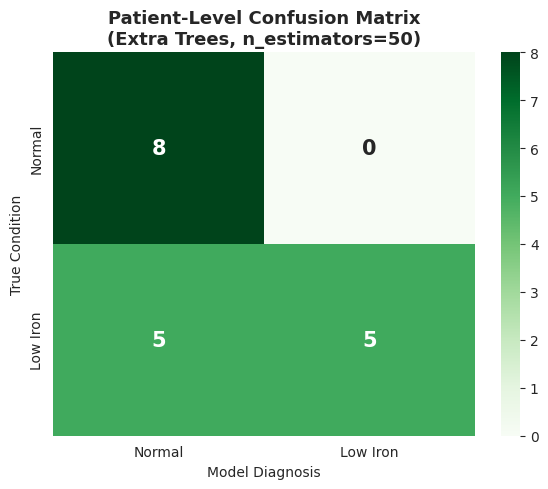

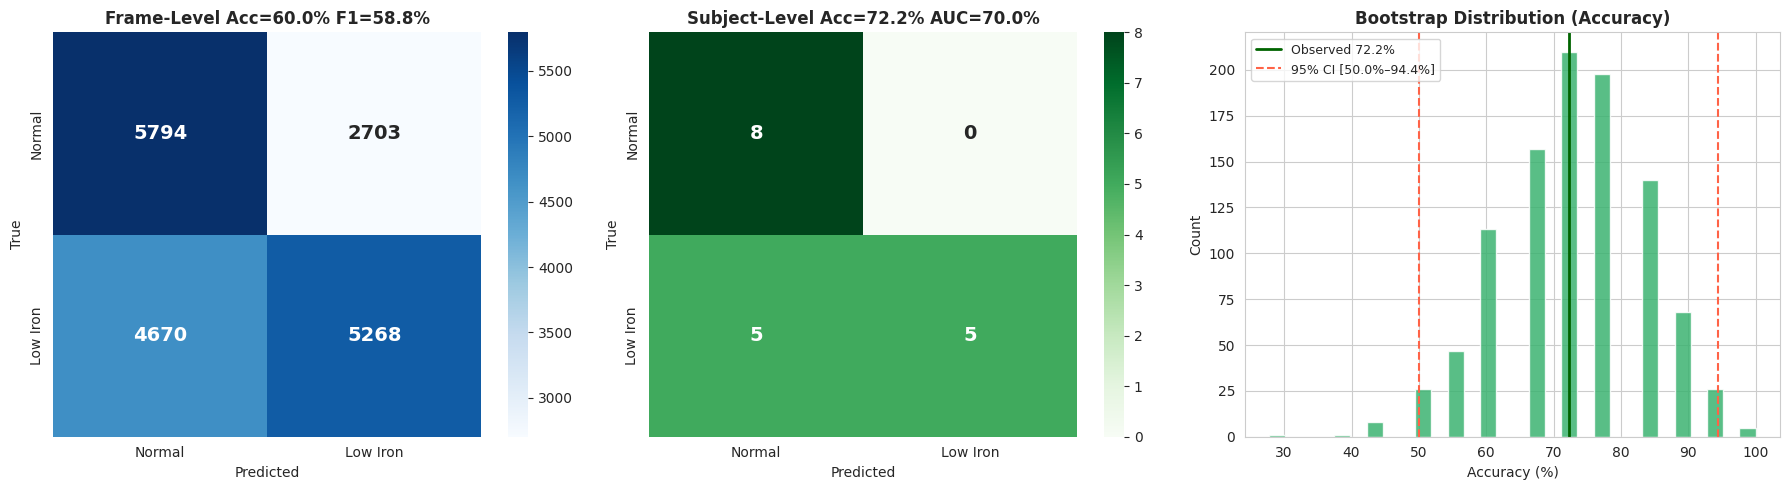


Subject-Level Classification Report
              precision    recall  f1-score   support

      Normal       0.62      1.00      0.76         8
    Low Iron       1.00      0.50      0.67        10

    accuracy                           0.72        18
   macro avg       0.81      0.75      0.71        18
weighted avg       0.83      0.72      0.71        18



In [112]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
from sklearn.model_selection import LeaveOneGroupOut
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.ensemble import ExtraTreesClassifier
from sklearn.metrics import (
    accuracy_score, recall_score, f1_score, precision_score,
    confusion_matrix, classification_report, roc_auc_score
)
import warnings, os, re, time

global_start_time = time.time()

if 'ml_df' not in locals() or ml_df.empty:
    print('Please run the feature extraction cell first to generate ml_df.')
elif 'best_features' not in locals():
    print('Please run the feature selection cell first to get best_features.')
else:
    def get_subject_id(filename):
        name = os.path.basename(str(filename)).upper()
        match = re.search(r'(?:R\d+[-_])([A-Z]+)', name)
        return match.group(1) if match else name

    ml_df['subject_id'] = ml_df['source_file'].apply(get_subject_id)

    # Use best_features from Feature Selection Cell
    FEATURES  = best_features
    best_n_est = best_n_estimators_from_prev_step if 'best_n_estimators_from_prev_step' in locals() else 50
    best_depth = None

    X      = ml_df[FEATURES].values
    y      = (ml_df['Condition'] == 'Low Iron').astype(int).values
    groups = ml_df['subject_id'].values
    logo   = LeaveOneGroupOut()

    print('-'*70)
    print('Extra Trees | LOSO Soft Voting + Bootstrap CI + Feature Importance')
    print(f'{len(X)} frames | {len(np.unique(groups))} subjects | {len(FEATURES)} features')
    print(f'Using n_estimators: {best_n_est}, max_depth: {best_depth}')
    print('-'*70)

    frame_true, frame_pred, frame_proba     = [], [], []
    subject_true, subject_pred, subject_proba = [], [], []
    subject_details = []
    all_importances = []

    for train_idx, test_idx in logo.split(X, y, groups):
        X_train, X_test = X[train_idx], X[test_idx]
        y_train, y_test = y[train_idx], y[test_idx]

        pipeline = Pipeline([
            ('scaler',     StandardScaler()),
            ('classifier', ExtraTreesClassifier(
                n_estimators=best_n_est,
                max_depth=best_depth,
                class_weight='balanced',
                random_state=42,
                n_jobs=-1
            ))
        ])
        pipeline.fit(X_train, y_train)
        all_importances.append(pipeline.named_steps['classifier'].feature_importances_)

        y_pred_frames  = pipeline.predict(X_test)
        y_proba_frames = pipeline.predict_proba(X_test)[:, 1]

        frame_true.extend(y_test.tolist())
        frame_pred.extend(y_pred_frames.tolist())
        frame_proba.extend(y_proba_frames.tolist())

        soft_score    = float(np.mean(y_proba_frames))
        soft_decision = 1 if soft_score >= 0.5 else 0
        true_label    = int(y_test[0])
        subject_name  = groups[test_idx][0]

        subject_true.append(true_label)
        subject_pred.append(soft_decision)
        subject_proba.append(soft_score)

        vote_counts    = Counter(y_pred_frames)
        total_frames   = len(y_pred_frames)
        low_iron_votes = vote_counts.get(1, 0)
        normal_votes   = vote_counts.get(0, 0)

        subject_details.append([
            subject_name,
            'Low Iron' if true_label == 1 else 'Normal',
            f'{soft_score:.2f}',
            f'{low_iron_votes}/{total_frames}',
            f'{normal_votes}/{total_frames}',
            'Low Iron' if soft_decision == 1 else 'Normal',
            f'n_est={best_n_est}, depth={best_depth}',
            'Correct' if soft_decision == true_label else 'Incorrect'
        ])

    # --- Metrics ------------------------------------------------------------------
    f_acc  = accuracy_score(frame_true, frame_pred)                          * 100
    f_prec = precision_score(frame_true, frame_pred, zero_division=0)        * 100
    f_rec  = recall_score(frame_true, frame_pred, zero_division=0)           * 100
    f_f1   = f1_score(frame_true, frame_pred, zero_division=0)               * 100

    s_acc  = accuracy_score(subject_true, subject_pred)                      * 100
    s_prec = precision_score(subject_true, subject_pred, zero_division=0)    * 100
    s_rec  = recall_score(subject_true, subject_pred, zero_division=0)       * 100
    s_f1   = f1_score(subject_true, subject_pred, zero_division=0)           * 100
    try:
        s_auc = roc_auc_score(subject_true, subject_proba) * 100
    except Exception:
        s_auc = float('nan')

    # --- Print Results -----------------------------------------------------------
    print("\n")
    print("FINAL RESULTS — Extra Trees (LOSO)")
    print("")
    print(f"  Features Used : {FEATURES}")
    print(f"  n_estimators  : {best_n_est}")

    print("\n  PATIENT-LEVEL METRICS")
    print("  " + "-" * 40)
    print(f"  Accuracy  : {s_acc:.1f}%")
    print(f"  Precision : {s_prec:.1f}%")
    print(f"  Recall    : {s_rec:.1f}%")
    print(f"  F1-Score  : {s_f1:.1f}%")
    print(f"  ROC-AUC   : {s_auc:.1f}%")

    print("\n  FRAME-LEVEL METRICS")
    print("  " + "-" * 40)
    print(f"  Accuracy  : {f_acc:.1f}%")
    print(f"  Precision : {f_prec:.1f}%")
    print(f"  Recall    : {f_rec:.1f}%")
    print(f"  F1-Score  : {f_f1:.1f}%")
    print("")
    print(f"\nRuntime: {(time.time() - global_start_time) / 60:.2f} min")

    # --- Bootstrap CI -------------------------------------------------------------
    np.random.seed(42)
    boot_accs = [
        accuracy_score(
            np.array(subject_true)[idx := np.random.choice(len(subject_true), len(subject_true), replace=True)],
            np.array(subject_pred)[idx]
        ) * 100
        for _ in range(1000)
    ]
    ci_lo = np.percentile(boot_accs, 2.5)
    ci_hi = np.percentile(boot_accs, 97.5)
    print(f'\nBootstrap 95% CI Subject Accuracy: [{ci_lo:.1f}% – {ci_hi:.1f}%]')

    # --- Feature Importance -------------------------------------------------------
    print('\n' + '-'*70)
    print('Feature Importance Analysis (Mean Gini Impurity Decrease)')
    print('-'*70)
    imp_df   = pd.DataFrame(all_importances, columns=FEATURES)
    mean_imp = imp_df.mean()
    std_imp  = imp_df.std()
    for feat in mean_imp.sort_values(ascending=False).index:
        print(f'  {feat:<25}  {mean_imp[feat]:.4f}  ±{std_imp[feat]:.4f}')

    # --- Subject Table ------------------------------------------------------------
    print('\n' + '-'*70)
    details_df = pd.DataFrame(subject_details, columns=[
        'Subject', 'True Condition', 'Soft Score',
        'Low Iron Votes', 'Normal Votes',
        'Predicted Condition', 'Model Params', 'Prediction Result'
    ])
    display(details_df)

    # --- Plots --------------------------------------------------------------------
    # Patient-Level Confusion Matrix
    cm = confusion_matrix(subject_true, subject_pred)
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Greens',
                xticklabels=['Normal', 'Low Iron'],
                yticklabels=['Normal', 'Low Iron'],
                annot_kws={"size": 15, "weight": "bold"})
    plt.title(f'Patient-Level Confusion Matrix\n(Extra Trees, n_estimators={best_n_est})',
              fontsize=13, fontweight='bold')
    plt.ylabel('True Condition'); plt.xlabel('Model Diagnosis')
    plt.tight_layout(); plt.show()

    # Frame + Subject + Bootstrap
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    sns.heatmap(confusion_matrix(frame_true, frame_pred),
                annot=True, fmt='d', cmap='Blues',
                xticklabels=['Normal','Low Iron'],
                yticklabels=['Normal','Low Iron'],
                annot_kws={'size':14,'weight':'bold'}, ax=axes[0])
    axes[0].set_title(f'Frame-Level Acc={f_acc:.1f}% F1={f_f1:.1f}%',
                      fontsize=12, fontweight='bold')
    axes[0].set_ylabel('True'); axes[0].set_xlabel('Predicted')

    sns.heatmap(confusion_matrix(subject_true, subject_pred),
                annot=True, fmt='d', cmap='Greens',
                xticklabels=['Normal','Low Iron'],
                yticklabels=['Normal','Low Iron'],
                annot_kws={'size':14,'weight':'bold'}, ax=axes[1])
    axes[1].set_title(f'Subject-Level Acc={s_acc:.1f}% AUC={s_auc:.1f}%',
                      fontsize=12, fontweight='bold')
    axes[1].set_ylabel('True'); axes[1].set_xlabel('Predicted')

    axes[2].hist(boot_accs, bins=30, color='mediumseagreen', edgecolor='white', alpha=0.85)
    axes[2].axvline(s_acc, color='darkgreen', linewidth=2, label=f'Observed {s_acc:.1f}%')
    axes[2].axvline(ci_lo, color='tomato', linewidth=1.5, linestyle='--', label=f'95% CI [{ci_lo:.1f}%–{ci_hi:.1f}%]')
    axes[2].axvline(ci_hi, color='tomato', linewidth=1.5, linestyle='--')
    axes[2].set_title('Bootstrap Distribution (Accuracy)', fontsize=12, fontweight='bold')
    axes[2].set_xlabel('Accuracy (%)'); axes[2].set_ylabel('Count')
    axes[2].legend(fontsize=9)

    plt.tight_layout(); plt.show()

    # Classification Report
    print('\nSubject-Level Classification Report')
    print(classification_report(subject_true, subject_pred,
                                 target_names=['Normal', 'Low Iron']))

    # --- Export Variables -------------------------------------------------
    best_overall_features = FEATURES
    true_patient_labels   = subject_true
    best_overall_preds    = subject_pred
    best_overall_f1       = s_f1
    best_frame_acc        = f_acc
    best_frame_precision  = f_prec
    best_frame_recall     = f_rec
    best_frame_f1         = f_f1

Building SHAP explainer for Extra Trees...


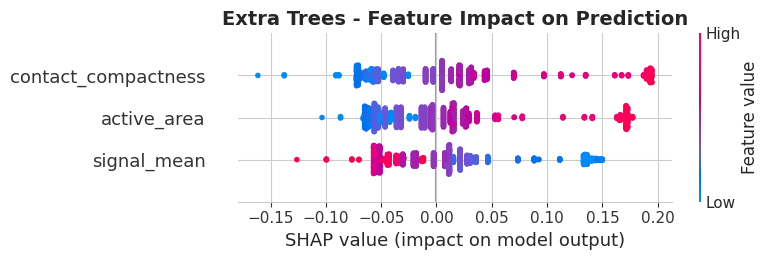

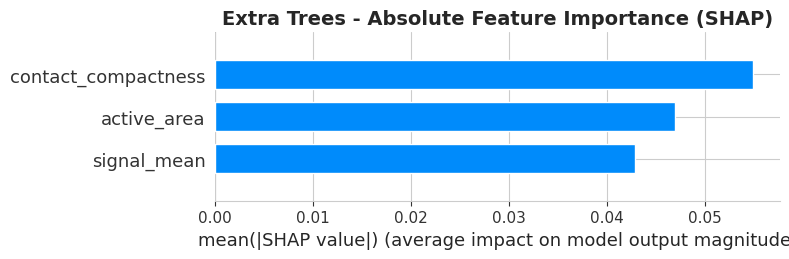

In [113]:
import shap
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import ExtraTreesClassifier
from sklearn.pipeline import Pipeline

shap.initjs()

# FEATURES is already defined in cell-02
# X = final_df[FEATURES].values
# y = (final_df['Condition'] == 'Low Iron').astype(int).values

print('Building SHAP explainer for Extra Trees...')

final_pipeline = Pipeline([
    ('scaler',     StandardScaler()),
    ('classifier', ExtraTreesClassifier(
        n_estimators=best_n_iter,          # Using optimal n_estimators from cell-02
        max_depth=best_params_list[-1][1], # Using optimal max_depth from cell-02
        class_weight='balanced',
        random_state=42,
        n_jobs=-1
    ))
])
final_pipeline.fit(X, y)

X_scaled = final_pipeline.named_steps['scaler'].transform(X)
model    = final_pipeline.named_steps['classifier']

# Quick Fix: sample 1000 frames instead of all data
rng = np.random.default_rng(42)
sample_idx = rng.choice(len(X_scaled), size=1000, replace=False)
X_sample   = X_scaled[sample_idx]
y_sample   = y[sample_idx]

explainer   = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_sample)   # on 1000 frames only

if isinstance(shap_values, list):
    sv = shap_values[1]
else:
    sv = shap_values[:, :, 1]

base_val = (explainer.expected_value[1]
            if isinstance(explainer.expected_value, (list, np.ndarray))
            else explainer.expected_value)

# Plot 1 -- Beeswarm
plt.figure(figsize=(10, 6))
shap.summary_plot(sv, X_sample, feature_names=FEATURES, show=False)
plt.title('Extra Trees - Feature Impact on Prediction', fontsize=14, fontweight='bold')
plt.tight_layout(); plt.show()

# Plot 2 -- Bar
plt.figure(figsize=(10, 5))
shap.summary_plot(sv, X_sample, feature_names=FEATURES, plot_type='bar', show=False)
plt.title('Extra Trees - Absolute Feature Importance (SHAP)', fontsize=14, fontweight='bold')
plt.tight_layout(); plt.show()

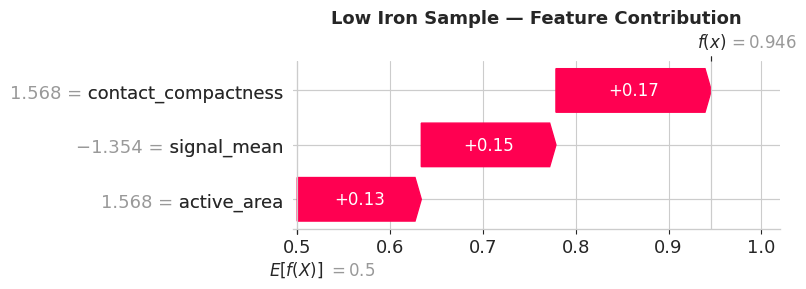

SHAP explanation complete.


In [114]:

# Plot 3 — Waterfall
low_iron_idx_local = np.where(y_sample == 1)[0][0]
if isinstance(shap_values, list):
    sv_class1 = shap_values[1]
else:
    sv_class1 = shap_values[:, :, 1]

import pandas as pd
shap_explanation = shap.Explanation(
    values        = sv_class1[low_iron_idx_local],
    base_values   = float(base_val),
    data          = pd.Series(X_sample[low_iron_idx_local], index=FEATURES),
    feature_names = FEATURES
)
shap.plots.waterfall(shap_explanation, show=False)
plt.title('Low Iron Sample — Feature Contribution', fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()

print('SHAP explanation complete.')